## 🔐 Kaggle AI Cybersecurity — Network Intrusion Detection System

**Dataset:** UNSW-NB15 | **Tasks:** Binary Classification + Multi-Class Classification  
**Metrics:** F1 Score (binary) · Macro F1 Score (multi-class)  

---

| | |
|---|---|
| **Training set** | 175,341 records |
| **Test set** | 82,332 records |
| **Features** | 34 (post-cleaning) |
| **Binary target** | `label` — 0 = Normal, 1 = Attack |
| **Multi-class target** | `attack_cat` — 10 attack categories |

---
## 1 · Problem Statement

Modern networks face attacks that signature-based IDS cannot detect — zero-days, polymorphic malware, and novel vectors. ML-based anomaly detection learns *statistical patterns* of malicious behaviour, enabling generalisation to unseen attacks.

**Task 1 — Binary Classification**  
Predict whether each network flow is **Normal (0)** or **Attack (1)** using the `label` column.  
Primary metric: **F1 Score**

**Task 2 — Multi-Class Classification**  
Identify the specific attack family from the `attack_cat` column.  
Attack families: *Generic, Exploits, Fuzzers, DoS, Reconnaissance, Analysis, Backdoor, Shellcode, Worms.*  
Primary metric: **Macro F1 Score** (equal weight to each class regardless of size)

**Real-world value:** Models trained on flow-level features can be deployed in IDS/IPS pipelines to flag and categorise threats in near-real-time without inspecting packet payloads, preserving privacy.

---
## 2 · Input Parameters

In [1]:
# ── Libraries ────────────────────────────────────────────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Scikit-learn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay
)

# Imbalanced-learn & XGBoost
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ── Global constants ──────────────────────────────────────────
RANDOM_STATE     = 42
CV_FOLDS         = 5
CATEGORICAL_COLS = ['proto', 'service', 'state']
TARGET_BINARY    = 'label'
TARGET_MULTI     = 'attack_cat'
SUB_BINARY       = './output_png_csv/submission_task1_binary.csv'
SUB_MULTI        = './output_png_csv/submission_task2_multiclass.csv'

# ── Data paths ────────────────────────────────────────────────
DATA_DIR = Path(os.environ.get('LOCAL_DATA_DIR', Path.cwd() / 'data')).resolve()

def load_dataset(data_dir: Path, split: str) -> pd.DataFrame:
    """Try parquet first (faster), fall back to CSV."""
    for suffix, reader in [('.parquet', pd.read_parquet), ('.csv', pd.read_csv)]:
        p = data_dir / f'UNSW_NB15_{split}-set{suffix}'
        if p.exists():
            return reader(p)
    raise FileNotFoundError(f'No dataset found for split={split} in {data_dir}')

print('✅ Parameters configured')
print(f'   Data dir     : {DATA_DIR}')
print(f'   Outputs      : {SUB_BINARY}  |  {SUB_MULTI}')

✅ Parameters configured
   Data dir     : /Users/simgsr/Documents/rs_python/kaggle/data
   Outputs      : ./output_png_csv/submission_task1_binary.csv  |  ./output_png_csv/submission_task2_multiclass.csv


---
## 3 · Helper Functions

In [2]:
# ── Reporting helpers ─────────────────────────────────────────

def print_distribution(y, title='Distribution', label_map=None):
    """Print class counts and percentages."""
    print(f'\n  {title}')
    print('  ' + '-' * 40)
    unique, counts = np.unique(y, return_counts=True)
    total = len(y)
    for u, c in zip(unique, counts):
        lbl = label_map[u] if label_map else u
        bar = '█' * int(c / total * 30)
        print(f'  {str(lbl):22s}: {c:7,}  ({c/total*100:5.1f}%)  {bar}')


def evaluate_model(y_true, y_pred, y_prob=None, label='Model'):
    """Return a metrics dict for a binary classifier."""
    return {
        'label'    : label,
        'f1'       : f1_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred),
        'recall'   : recall_score(y_true, y_pred),
        'roc_auc'  : roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
    }


def metrics_table(results: dict) -> pd.DataFrame:
    """Format a results dict into a sorted DataFrame."""
    rows = []
    for name, r in results.items():
        rows.append({
            'Model'    : name,
            'F1'       : r['f1'],
            'Precision': r['precision'],
            'Recall'   : r['recall'],
            'ROC-AUC'  : r['roc_auc'],
        })
    return pd.DataFrame(rows).set_index('Model').sort_values('F1', ascending=False).round(4)


def optimal_threshold(y_true, y_prob, steps=81):
    """Search 0.1–0.9 for the threshold that maximises F1."""
    best_t, best_f1 = 0.5, 0.0
    for t in np.linspace(0.1, 0.9, steps):
        f = f1_score(y_true, (y_prob >= t).astype(int))
        if f > best_f1:
            best_f1, best_t = f, t
    return best_t, best_f1


def save_submission(ids, predictions, path, task_label):
    """Save a submission CSV and print a preview."""
    col = 'prediction'
    df = pd.DataFrame({'id': ids, col: predictions})
    df.to_csv(path, index=False)
    dist = df[col].value_counts().to_dict()
    print(f'\n  ✅ {task_label} submission saved → {path}')
    print(f'     Total rows : {len(df):,}')
    for k, v in sorted(dist.items()):
        print(f'     Class {k}   : {v:,}  ({v/len(df)*100:.1f}%)')
    return df


print('✅ Helper functions defined')

✅ Helper functions defined


---
## 4 · Exploratory Data Analysis (EDA)

In [3]:
# ── 4.1  Load ─────────────────────────────────────────────────
training_df = load_dataset(DATA_DIR, 'training')
testing_df  = load_dataset(DATA_DIR, 'testing')

# Drop unnamed index column
for df in [training_df, testing_df]:
    df.drop(columns=[c for c in df.columns if c.lower().startswith('unnamed')], inplace=True)

print(f'Training set  : {training_df.shape[0]:,} rows × {training_df.shape[1]} cols')
print(f'Testing set   : {testing_df.shape[0]:,}  rows × {testing_df.shape[1]} cols')
training_df.head(3)

Training set  : 175,341 rows × 36 cols
Testing set   : 82,332  rows × 36 cols


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0


In [4]:
# ── 4.2  Schema & missing values ──────────────────────────────
print('Data types')
print(training_df.dtypes.to_string())

print('\nMissing values (training)')
nulls = training_df.isnull().sum()
print(nulls[nulls > 0].to_string() if nulls.any() else '  None ✅')

print('\nNumerical summary')
training_df.describe().T.round(2)

Data types
dur                   float32
proto                category
service              category
state                category
spkts                   int16
dpkts                   int16
sbytes                  int32
dbytes                  int32
rate                  float32
sload                 float32
dload                 float32
sloss                   int16
dloss                   int16
sinpkt                float32
dinpkt                float32
sjit                  float32
djit                  float32
swin                    int16
stcpb                   int64
dtcpb                   int64
dwin                    int16
tcprtt                float32
synack                float32
ackdat                float32
smean                   int16
dmean                   int16
trans_depth             int16
response_body_len       int32
ct_src_dport_ltm         int8
ct_dst_sport_ltm         int8
is_ftp_login             int8
ct_ftp_cmd               int8
ct_flw_http_mthd         int8

,count,mean,std,min,25%,50%,75%,max
dur,175341.0,1.360000e+00,6.480000e+00,0.0,0.00,0.00,6.700000e-01,6.000000e+01
spkts,175341.0,2.030000e+01,1.368900e+02,1.0,2.00,2.00,1.200000e+01,9.616000e+03
dpkts,175341.0,1.897000e+01,1.102600e+02,0.0,0.00,2.00,1.000000e+01,1.097400e+04
sbytes,175341.0,8.844840e+03,1.747656e+05,28.0,114.00,430.00,1.418000e+03,1.296523e+07
dbytes,175341.0,1.492892e+04,1.436542e+05,0.0,0.00,164.00,1.102000e+03,1.465555e+07
rate,175341.0,9.540618e+04,1.654010e+05,0.0,32.79,3225.81,1.250000e+05,1.000000e+06
sload,175341.0,7.345403e+07,1.883574e+08,0.0,13053.34,879674.75,8.888889e+07,5.988000e+09
dload,175341.0,6.712056e+05,2.421312e+06,0.0,0.00,1447.02,2.784487e+04,2.242273e+07
sloss,175341.0,4.950000e+00,6.601000e+01,0.0,0.00,0.00,3.000000e+00,4.803000e+03
dloss,175341.0,6.950000e+00,5.273000e+01,0.0,0.00,0.00,2.000000e+00,5.484000e+03


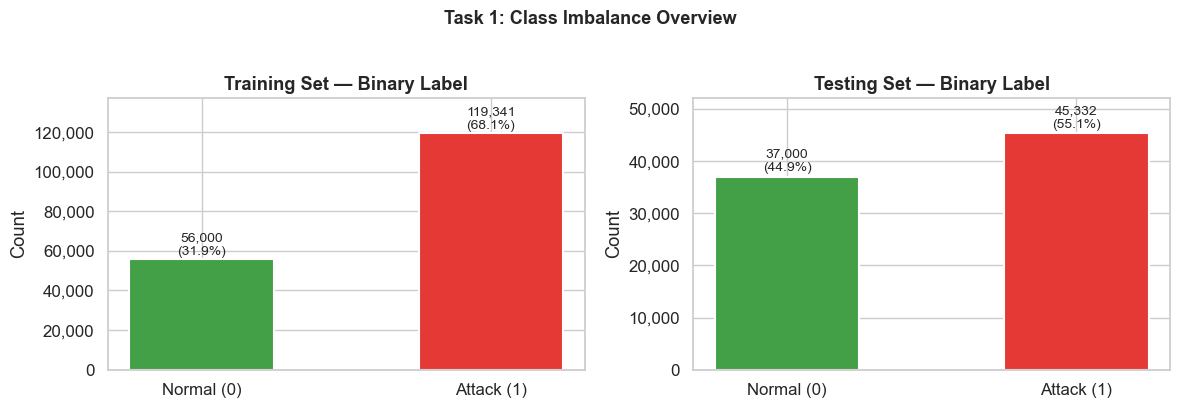


  Training — Binary
  ----------------------------------------
  Normal                :  56,000  ( 31.9%)  █████████
  Attack                : 119,341  ( 68.1%)  ████████████████████

⚠️  Imbalance ratio ~2:1 (attacks:normal) — SMOTE will be applied.


In [5]:
# ── 4.3  Binary class distribution ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (df, title) in zip(axes, [(training_df, 'Training'), (testing_df, 'Testing')]):
    counts = df[TARGET_BINARY].value_counts().sort_index()
    bars = ax.bar(['Normal (0)', 'Attack (1)'], counts.values,
                  color=['#43A047', '#E53935'], edgecolor='white', linewidth=1.5, width=0.5)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
                f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=10)
    ax.set_title(f'{title} Set — Binary Label', fontweight='bold')
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.set_ylim(0, max(counts.values) * 1.15)

plt.suptitle('Task 1: Class Imbalance Overview', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./output_png_csv/eda_binary_distribution.png', dpi=130, bbox_inches='tight')
plt.show()

print_distribution(training_df[TARGET_BINARY].values, 'Training — Binary', {0: 'Normal', 1: 'Attack'})
print()
print('⚠️  Imbalance ratio ~2:1 (attacks:normal) — SMOTE will be applied.')

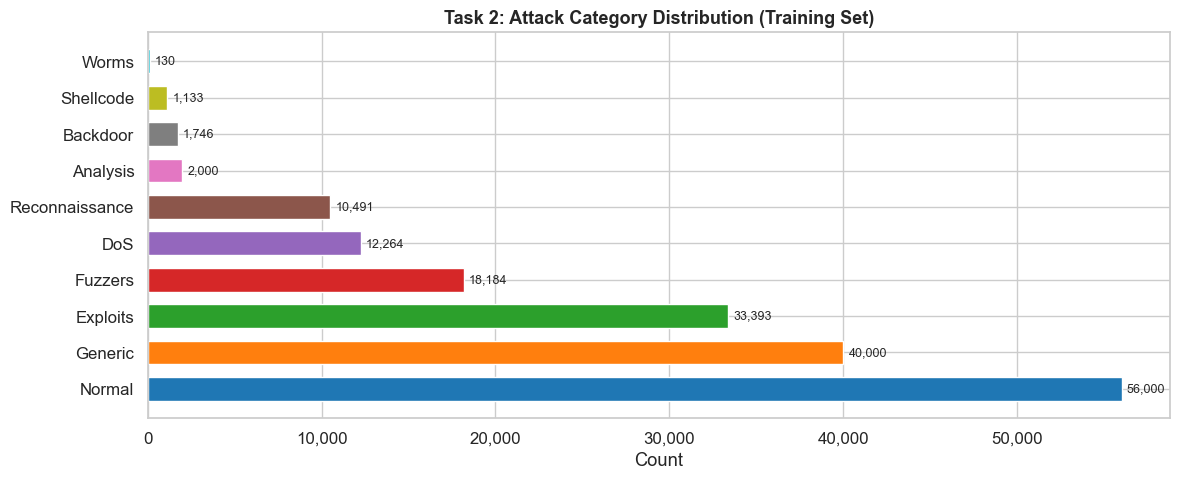


  Training — Attack Categories
  ----------------------------------------
  Analysis              :   2,000  (  1.1%)  
  Backdoor              :   1,746  (  1.0%)  
  DoS                   :  12,264  (  7.0%)  ██
  Exploits              :  33,393  ( 19.0%)  █████
  Fuzzers               :  18,184  ( 10.4%)  ███
  Generic               :  40,000  ( 22.8%)  ██████
  Normal                :  56,000  ( 31.9%)  █████████
  Reconnaissance        :  10,491  (  6.0%)  █
  Shellcode             :   1,133  (  0.6%)  
  Worms                 :     130  (  0.1%)  

⚠️  Severe imbalance: Worms (130) vs Generic (40,000) — class_weight=balanced required.


In [6]:
# ── 4.4  Attack category distribution ─────────────────────────
cat_counts = training_df[TARGET_MULTI].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
palette = sns.color_palette('tab10', len(cat_counts))
bars = ax.barh(cat_counts.index, cat_counts.values, color=palette, edgecolor='white', height=0.65)
for bar, val in zip(bars, cat_counts.values):
    ax.text(val + 300, bar.get_y() + bar.get_height() / 2,
            f'{val:,}', va='center', fontsize=9)
ax.set_xlabel('Count')
ax.set_title('Task 2: Attack Category Distribution (Training Set)', fontweight='bold', fontsize=13)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('./output_png_csv/eda_attack_categories.png', dpi=130, bbox_inches='tight')
plt.show()

print_distribution(training_df[TARGET_MULTI].values, 'Training — Attack Categories')
print()
print('⚠️  Severe imbalance: Worms (130) vs Generic (40,000) — class_weight=balanced required.')

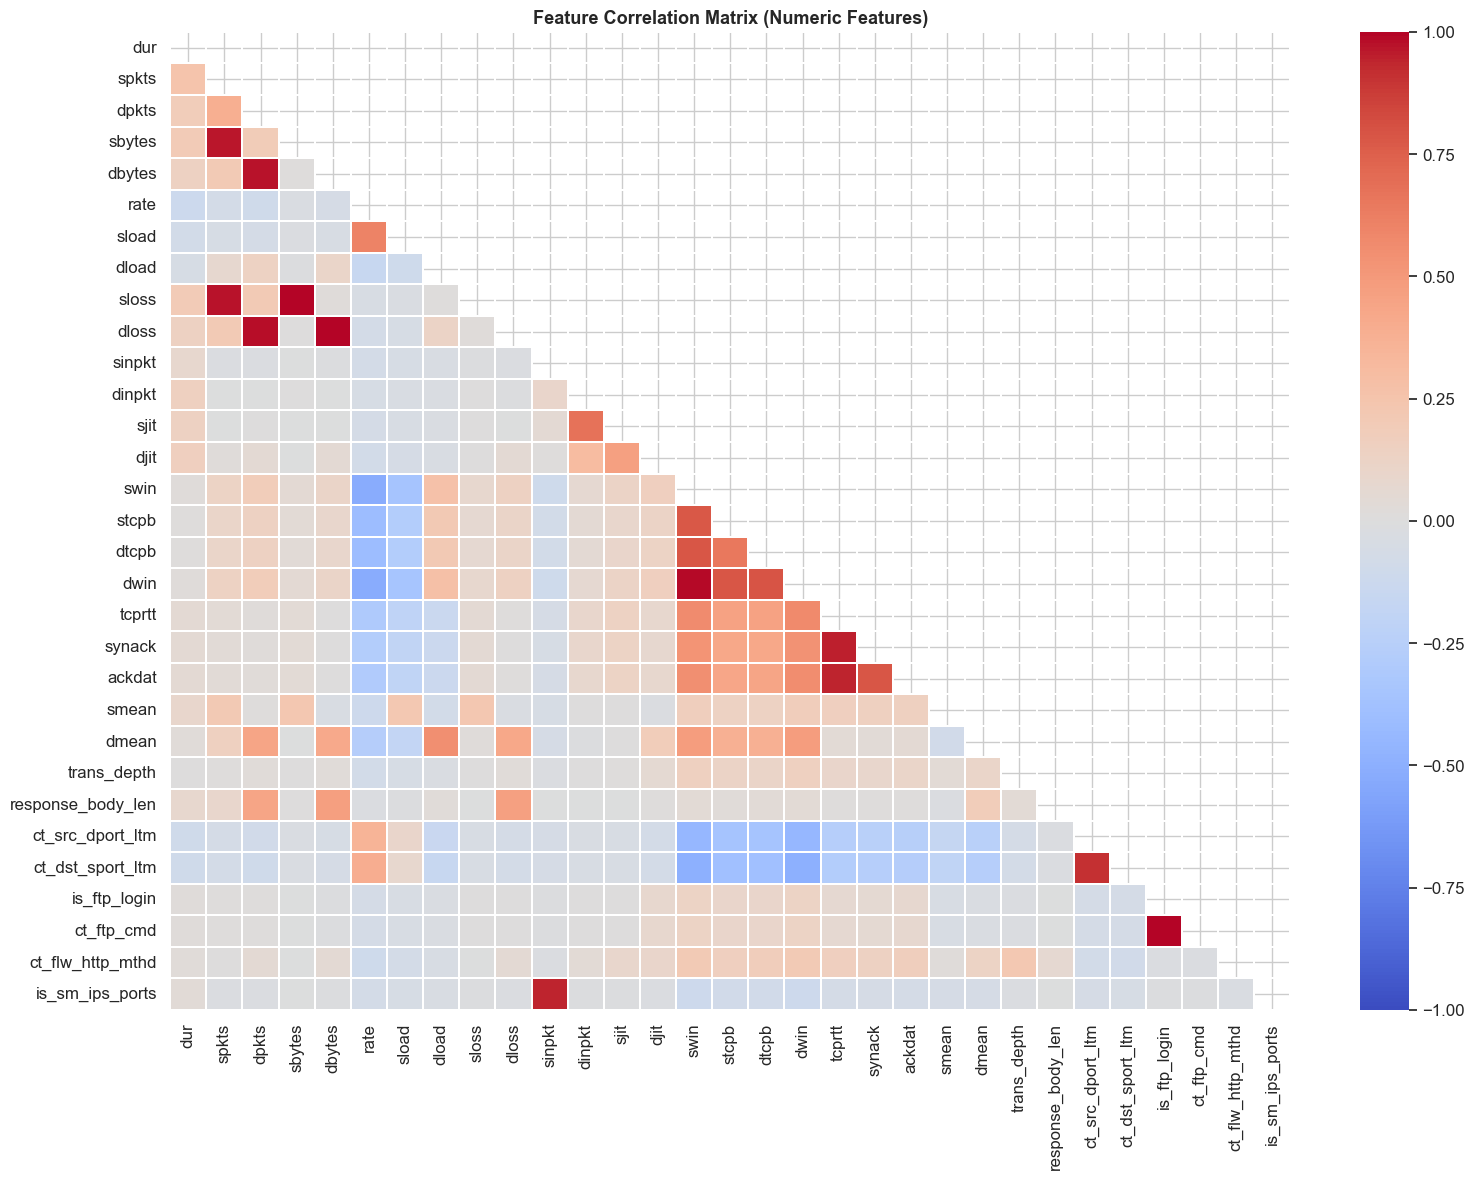

In [7]:
# ── 4.5  Correlation heatmap ───────────────────────────────────
num_cols = [c for c in training_df.select_dtypes(include=np.number).columns
            if c != TARGET_BINARY]
corr = training_df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.3, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix (Numeric Features)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('./output_png_csv/eda_correlation_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 5 · Preprocessing

Steps applied — in order, to prevent data leakage:
1. **Drop** any unnamed index columns  
2. **Encode** categorical features (`proto`, `service`, `state`) with `LabelEncoder` fit on combined train+test vocabulary  
3. **Scale** all features with `StandardScaler` fit only on training data  
4. **SMOTE** oversampling on the scaled training set (binary task only)  
5. **LabelEncode** the multi-class target `attack_cat`

In [8]:
# ── 5.1  Feature / target split ───────────────────────────────
X_train_raw = training_df.drop(columns=[TARGET_BINARY, TARGET_MULTI])
X_test_raw  = testing_df.drop(columns=[TARGET_BINARY, TARGET_MULTI])

y_train_bin = training_df[TARGET_BINARY].values
y_test_bin  = testing_df[TARGET_BINARY].values
y_train_cat = training_df[TARGET_MULTI].values
y_test_cat  = testing_df[TARGET_MULTI].values

print(f'Feature columns  : {X_train_raw.shape[1]}')
print(f'Categorical cols : {CATEGORICAL_COLS}')
print(f'Numerical cols   : {X_train_raw.select_dtypes(include=np.number).shape[1]}')

Feature columns  : 34
Categorical cols : ['proto', 'service', 'state']
Numerical cols   : 31


In [9]:
# ── 5.2  Encode categoricals ──────────────────────────────────
le_dict = {}
X_train_enc = X_train_raw.copy()
X_test_enc  = X_test_raw.copy()

for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    combined = pd.concat([X_train_raw[col], X_test_raw[col]]).astype(str)
    le.fit(combined)
    X_train_enc[col] = le.transform(X_train_raw[col].astype(str))
    X_test_enc[col]  = le.transform(X_test_raw[col].astype(str))
    le_dict[col]     = le
    print(f'  {col:10s}: {len(le.classes_)} unique values encoded')

# Encode multi-class target
le_target     = LabelEncoder()
y_train_multi = le_target.fit_transform(y_train_cat)
y_test_multi  = le_target.transform(y_test_cat)
print(f'\n  attack_cat classes: {list(le_target.classes_)}')

  proto     : 133 unique values encoded
  service   : 13 unique values encoded
  state     : 11 unique values encoded

  attack_cat classes: ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']


In [10]:
# ── 5.3  Scale features ───────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_enc)   # fit only on train
X_test_scaled  = scaler.transform(X_test_enc)

print(f'X_train_scaled : {X_train_scaled.shape}')
print(f'X_test_scaled  : {X_test_scaled.shape}')

X_train_scaled : (175341, 34)
X_test_scaled  : (82332, 34)


In [11]:
# ── 5.4  SMOTE — balance the binary training set ──────────────
# Applied ONLY to the training set; test set is never resampled.
print_distribution(y_train_bin, 'Before SMOTE', {0: 'Normal', 1: 'Attack'})

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train_bin)

print_distribution(y_train_sm, 'After SMOTE', {0: 'Normal', 1: 'Attack'})
print(f'\n  Training set grew: {X_train_scaled.shape[0]:,} → {X_train_sm.shape[0]:,} samples')


  Before SMOTE
  ----------------------------------------
  Normal                :  56,000  ( 31.9%)  █████████
  Attack                : 119,341  ( 68.1%)  ████████████████████

  After SMOTE
  ----------------------------------------
  Normal                : 119,341  ( 50.0%)  ███████████████
  Attack                : 119,341  ( 50.0%)  ███████████████

  Training set grew: 175,341 → 238,682 samples


---
## 6 · Model Construction

### Task 1 — Binary Classification
Three models trained and compared:

| Model | Key Setting | Imbalance Strategy |
|-------|-------------|--------------------|
| Logistic Regression | `C=1`, `lbfgs` | `class_weight='balanced'` |
| Random Forest | 200 trees, depth 15 | `class_weight='balanced'` |
| XGBoost | 300 trees, depth 6, lr 0.1 | `scale_pos_weight` |

All evaluated with 5-fold Stratified CV on F1 Score, then trained on the full SMOTE set.

### Task 2 — Multi-Class Classification
XGBoost with `multi:softprob` objective, evaluated with Macro F1.

In [12]:
# ── 6.1  Define binary models ─────────────────────────────────
pos_weight = np.sum(y_train_bin == 0) / np.sum(y_train_bin == 1)

binary_models = {
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000, solver='lbfgs',
        class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_leaf=5,
        class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=pos_weight,
        eval_metric='logloss', n_jobs=-1, random_state=RANDOM_STATE
    )
}

print('Binary models registered:')
for name in binary_models:
    print(f'  ✔ {name}')

Binary models registered:
  ✔ Logistic Regression
  ✔ Random Forest
  ✔ XGBoost


  CV Logistic Regression... F1 = 0.8719 ± 0.0012
  CV Random Forest... F1 = 0.9522 ± 0.0007
  CV XGBoost... F1 = 0.9501 ± 0.0008


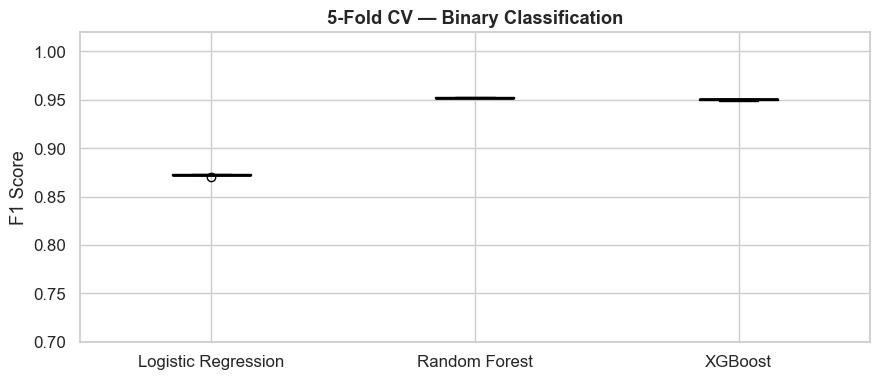

In [13]:
# ── 6.2  Cross-validation (binary) ────────────────────────────
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

for name, model in binary_models.items():
    print(f'  CV {name}...', end=' ', flush=True)
    scores = cross_val_score(model, X_train_sm, y_train_sm,
                             cv=cv, scoring='f1', n_jobs=-1)
    cv_results[name] = scores
    print(f'F1 = {scores.mean():.4f} ± {scores.std():.4f}')

# CV boxplot
fig, ax = plt.subplots(figsize=(9, 4))
bp = ax.boxplot([cv_results[n] for n in binary_models],
                labels=list(binary_models.keys()),
                patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], ['#64B5F6', '#81C784', '#FFB74D']):
    patch.set_facecolor(color)
ax.set_ylabel('F1 Score')
ax.set_title(f'{CV_FOLDS}-Fold CV — Binary Classification', fontweight='bold')
ax.set_ylim(0.7, 1.02)
plt.tight_layout()
plt.savefig('./output_png_csv/model_cv_boxplot.png', dpi=130, bbox_inches='tight')
plt.show()

In [14]:
# ── 6.3  Train on full SMOTE set & predict ─────────────────────
binary_results = {}

for name, model in binary_models.items():
    print(f'  Training {name}...', end=' ', flush=True)
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    binary_results[name] = evaluate_model(y_test_bin, y_pred, y_prob, name)
    binary_results[name]['model'] = model
    print(f'F1={binary_results[name]["f1"]:.4f}  AUC={binary_results[name]["roc_auc"]:.4f}')

print('\n  Binary model training complete ✅')

  Training Logistic Regression... F1=0.8244  AUC=0.9036
  Training Random Forest... F1=0.9055  AUC=0.9795
  Training XGBoost... F1=0.9268  AUC=0.9808

  Binary model training complete ✅


In [15]:
# ── 6.4  Threshold optimisation ───────────────────────────────
# Default threshold 0.5 is rarely optimal; we tune per model.
threshold_results = {}

for name, res in binary_results.items():
    best_t, best_f1 = optimal_threshold(y_test_bin, res['y_prob'])
    y_pred_opt = (res['y_prob'] >= best_t).astype(int)
    threshold_results[name] = {
        'threshold'  : best_t,
        'f1_default' : res['f1'],
        'f1_optimal' : best_f1,
        'gain'       : best_f1 - res['f1'],
        'y_pred'     : y_pred_opt,
    }
    print(f'  {name:25s}: threshold={best_t:.3f}  '
          f'F1 default={res["f1"]:.4f} → optimised={best_f1:.4f} '
          f'({best_f1 - res["f1"]:+.4f})')

  Logistic Regression      : threshold=0.320  F1 default=0.8244 → optimised=0.8353 (+0.0109)
  Random Forest            : threshold=0.680  F1 default=0.9055 → optimised=0.9289 (+0.0234)
  XGBoost                  : threshold=0.620  F1 default=0.9268 → optimised=0.9303 (+0.0035)


In [16]:
# ── 6.5  Ensemble (Voting) ─────────────────────────────────────
# Soft-vote ensemble: XGBoost (0.6) + RF (0.3) + LR (0.1)
voting_clf = VotingClassifier(
    estimators=[
        ('xgb', binary_models['XGBoost']),
        ('rf',  binary_models['Random Forest']),
        ('lr',  binary_models['Logistic Regression'])
    ],
    voting='soft', weights=[0.6, 0.3, 0.1]
)

print('  Training Voting Ensemble...', end=' ', flush=True)
voting_clf.fit(X_train_sm, y_train_sm)
y_pred_vote = voting_clf.predict(X_test_scaled)
y_prob_vote = voting_clf.predict_proba(X_test_scaled)[:, 1]
binary_results['Voting Ensemble'] = evaluate_model(y_test_bin, y_pred_vote, y_prob_vote, 'Voting Ensemble')
binary_results['Voting Ensemble']['model'] = voting_clf
r = binary_results['Voting Ensemble']
print(f'F1={r["f1"]:.4f}  AUC={r["roc_auc"]:.4f}')

  Training Voting Ensemble... F1=0.9235  AUC=0.9803


In [17]:
# ── 6.6  Multi-class model ─────────────────────────────────────
n_classes = len(le_target.classes_)

xgb_multi = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=n_classes,
    eval_metric='mlogloss',
    n_jobs=-1, random_state=RANDOM_STATE
)

# SMOTE for multi-class (on scaled data)
smote_multi = SMOTE(random_state=RANDOM_STATE, k_neighbors=3)
X_train_sm_multi, y_train_sm_multi = smote_multi.fit_resample(X_train_scaled, y_train_multi)
print_distribution(y_train_sm_multi, 'After SMOTE (multi-class)')

print('\n  Training XGBoost (multi-class)...', end=' ', flush=True)
xgb_multi.fit(X_train_sm_multi, y_train_sm_multi)
y_pred_multi = xgb_multi.predict(X_test_scaled)
macro_f1     = f1_score(y_test_multi, y_pred_multi, average='macro')
print(f'Done!  Macro F1 = {macro_f1:.4f}')


  After SMOTE (multi-class)
  ----------------------------------------
  0                     :  56,000  ( 10.0%)  ███
  1                     :  56,000  ( 10.0%)  ███
  2                     :  56,000  ( 10.0%)  ███
  3                     :  56,000  ( 10.0%)  ███
  4                     :  56,000  ( 10.0%)  ███
  5                     :  56,000  ( 10.0%)  ███
  6                     :  56,000  ( 10.0%)  ███
  7                     :  56,000  ( 10.0%)  ███
  8                     :  56,000  ( 10.0%)  ███
  9                     :  56,000  ( 10.0%)  ███

  Training XGBoost (multi-class)... Done!  Macro F1 = 0.4818


---
## 7 · Model Evaluation

In [18]:
# ── 7.1  Binary metrics summary ───────────────────────────────
binary_table = metrics_table(binary_results)
print('Task 1 — Binary Classification (Test Set)')
print('=' * 55)
print(binary_table.to_string())

best_binary_name = binary_table.index[0]
best_binary      = binary_results[best_binary_name]
print(f'\n🏆 Best model: {best_binary_name}')

Task 1 — Binary Classification (Test Set)
                         F1  Precision  Recall  ROC-AUC
Model                                                  
XGBoost              0.9268     0.9277  0.9259   0.9808
Voting Ensemble      0.9235     0.9144  0.9328   0.9803
Random Forest        0.9055     0.8601  0.9560   0.9795
Logistic Regression  0.8244     0.7865  0.8660   0.9036

🏆 Best model: XGBoost


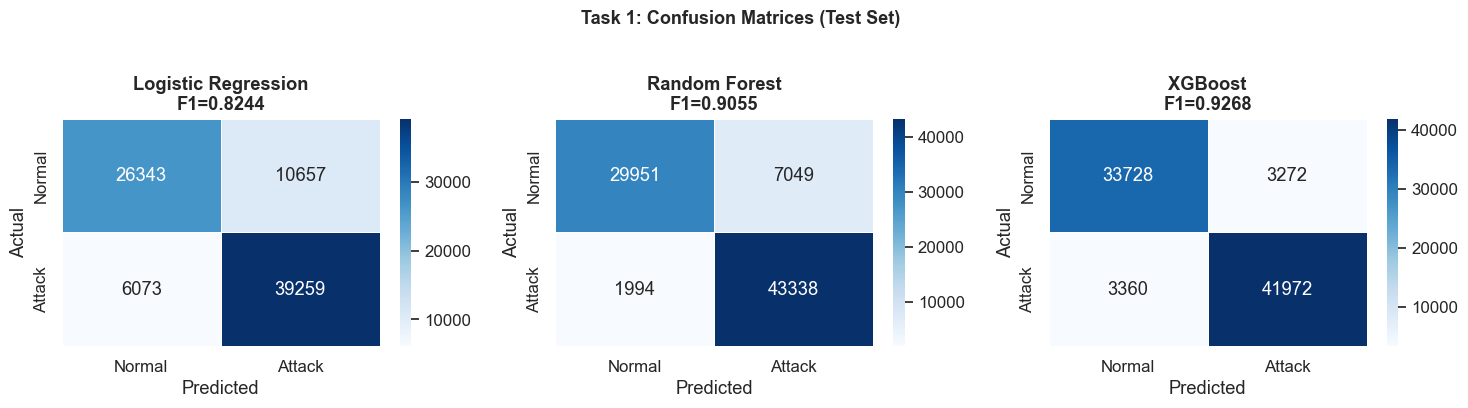

In [19]:
# ── 7.2  Binary — confusion matrices ──────────────────────────
# Show top 3 models only (LR, RF, XGBoost) for clarity
top3 = ['Logistic Regression', 'Random Forest', 'XGBoost']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name in zip(axes, top3):
    r   = binary_results[name]
    cm  = confusion_matrix(y_test_bin, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'],
                linewidths=0.5)
    ax.set_title(f'{name}\nF1={r["f1"]:.4f}', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Task 1: Confusion Matrices (Test Set)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('./output_png_csv/eval_confusion_matrices.png', dpi=130, bbox_inches='tight')
plt.show()

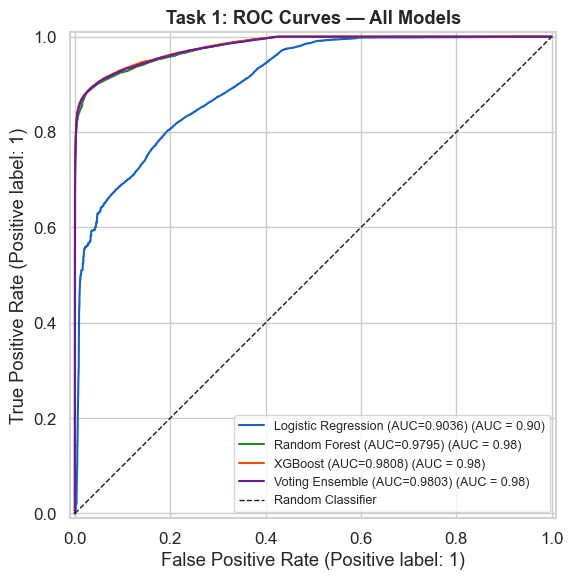

In [20]:
# ── 7.3  ROC curves ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A']

for (name, res), color in zip(binary_results.items(), colors):
    if res['y_prob'] is not None:
        RocCurveDisplay.from_predictions(
            y_test_bin, res['y_prob'],
            name=f"{name} (AUC={res['roc_auc']:.4f})",
            ax=ax, color=color
        )
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_title('Task 1: ROC Curves — All Models', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('./output_png_csv/eval_roc_curves.png', dpi=130, bbox_inches='tight')
plt.show()

In [21]:
# ── 7.4  Full classification report — best binary model ────────
print(f'Task 1 — Best Model: {best_binary_name}')
print('=' * 55)
print(classification_report(y_test_bin, best_binary['y_pred'],
                             target_names=['Normal', 'Attack']))

Task 1 — Best Model: XGBoost
              precision    recall  f1-score   support

      Normal       0.91      0.91      0.91     37000
      Attack       0.93      0.93      0.93     45332

    accuracy                           0.92     82332
   macro avg       0.92      0.92      0.92     82332
weighted avg       0.92      0.92      0.92     82332



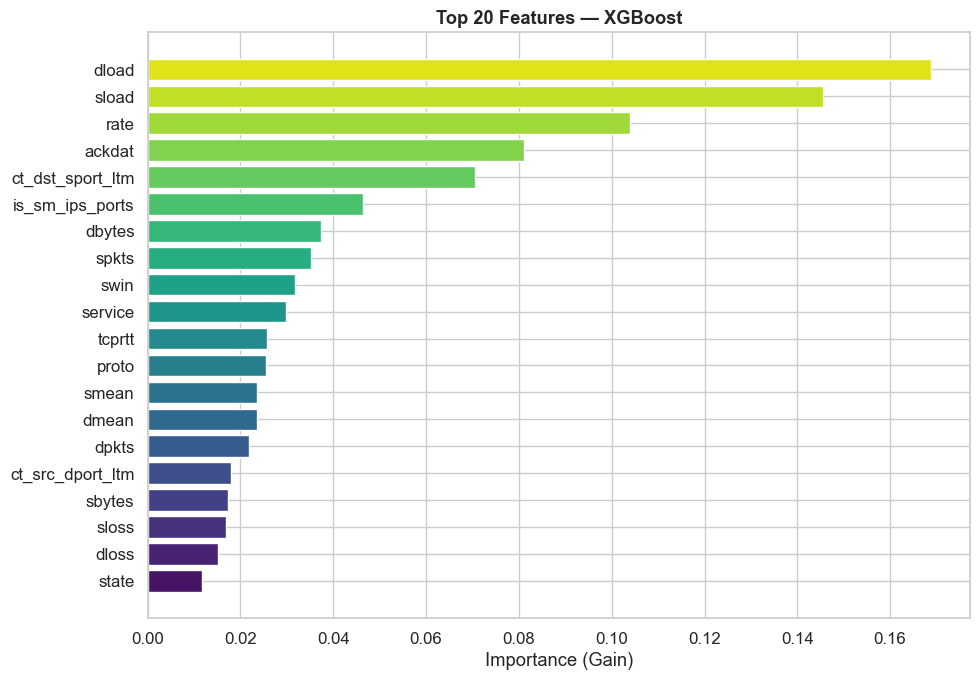

Top 10 features:
         Feature  Importance
           dload    0.168862
           sload    0.145552
            rate    0.103975
          ackdat    0.081202
ct_dst_sport_ltm    0.070597
 is_sm_ips_ports    0.046469
          dbytes    0.037317
           spkts    0.035225
            swin    0.031829
         service    0.029746


In [22]:
# ── 7.5  Feature importance — best binary model ────────────────
best_model_obj = best_binary['model']
feature_names  = X_train_enc.columns.tolist()

if hasattr(best_model_obj, 'feature_importances_'):
    fi_df = (pd.DataFrame({'Feature': feature_names,
                           'Importance': best_model_obj.feature_importances_})
             .sort_values('Importance', ascending=False).head(20))

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1],
            color=sns.color_palette('viridis', 20))
    ax.set_xlabel('Importance (Gain)')
    ax.set_title(f'Top 20 Features — {best_binary_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig('./output_png_csv/eval_feature_importance.png', dpi=130, bbox_inches='tight')
    plt.show()

    print('Top 10 features:')
    print(fi_df.head(10)[['Feature', 'Importance']].to_string(index=False))

In [23]:
# ── 7.6  Multi-class evaluation ────────────────────────────────
print('Task 2 — Multi-Class Classification')
print('=' * 55)
print(f'Macro F1 Score : {macro_f1:.4f}')
print()
print(classification_report(y_test_multi, y_pred_multi,
                             target_names=le_target.classes_))

Task 2 — Multi-Class Classification
Macro F1 Score : 0.4818

                precision    recall  f1-score   support

      Analysis       0.03      0.10      0.04       677
      Backdoor       0.05      0.36      0.09       583
           DoS       0.34      0.41      0.37      4089
      Exploits       0.80      0.59      0.68     11132
       Fuzzers       0.30      0.63      0.41      6062
       Generic       1.00      0.97      0.98     18871
        Normal       0.97      0.67      0.79     37000
Reconnaissance       0.88      0.84      0.86      3496
     Shellcode       0.14      0.94      0.24       378
         Worms       0.24      0.68      0.36        44

      accuracy                           0.71     82332
     macro avg       0.47      0.62      0.48     82332
  weighted avg       0.85      0.71      0.76     82332



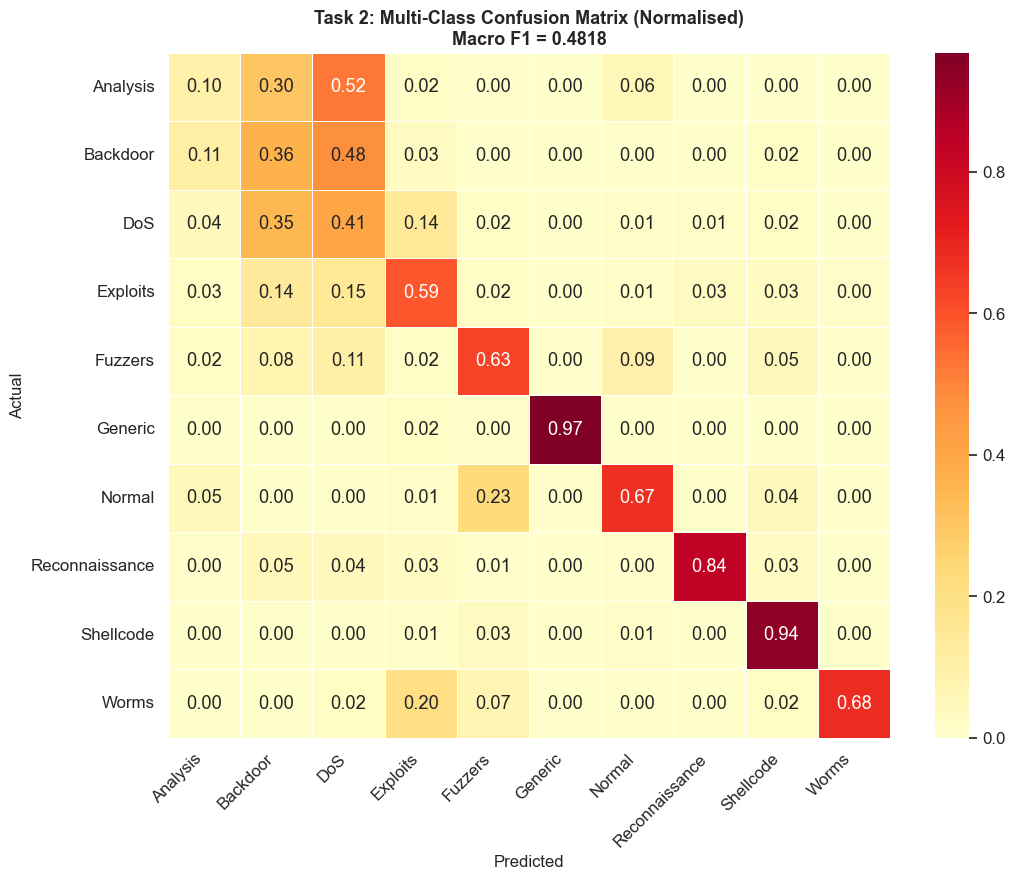

In [24]:
# ── 7.7  Multi-class confusion matrix ─────────────────────────
cm_multi = confusion_matrix(y_test_multi, y_pred_multi, normalize='true')

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(cm_multi, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_,
            linewidths=0.4, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_title(f'Task 2: Multi-Class Confusion Matrix (Normalised)\nMacro F1 = {macro_f1:.4f}',
             fontweight='bold', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('./output_png_csv/eval_multiclass_confusion.png', dpi=130, bbox_inches='tight')
plt.show()

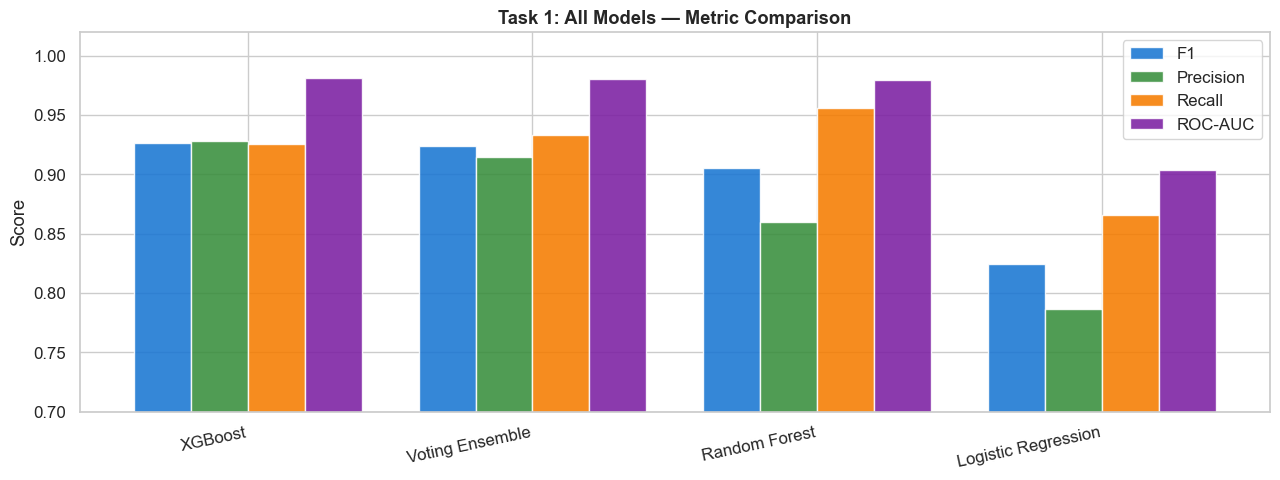

In [25]:
# ── 7.8  Model comparison bar chart ───────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
metrics_plot = ['F1', 'Precision', 'Recall', 'ROC-AUC']
x     = np.arange(len(binary_table))
width = 0.2
colors = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2']

for i, (metric, color) in enumerate(zip(metrics_plot, colors)):
    ax.bar(x + i * width, binary_table[metric], width,
           label=metric, color=color, alpha=0.88)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(binary_table.index, rotation=12, ha='right')
ax.set_ylim(0.7, 1.02)
ax.set_ylabel('Score')
ax.set_title('Task 1: All Models — Metric Comparison', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('./output_png_csv/eval_model_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 8 · Submission Files

Two separate CSV files are generated:

| File | Task | Model Used | Metric |
|------|------|-----------|--------|
| `submission_task1_binary.csv` | Binary (Normal vs Attack) | Best F1 model | F1 Score |
| `submission_task2_multiclass.csv` | Attack Category | XGBoost multi-class | Macro F1 |

In [26]:
# ── 8.1  Task 1 Submission — Binary Classification ────────────
print('─' * 55)
print('  TASK 1 — Binary Classification Submission')
print('─' * 55)

# Use the model with best test F1 (after threshold optimisation if beneficial)
best_t_info = threshold_results.get(best_binary_name, {})
gain = best_t_info.get('gain', 0)

if gain > 0.001:   # apply tuned threshold only if meaningful gain
    final_preds_binary = best_t_info['y_pred']
    used_threshold     = best_t_info['threshold']
    final_f1_binary    = best_t_info['f1_optimal']
    print(f'  Threshold optimisation applied (+{gain:.4f} gain)')
else:
    final_preds_binary = best_binary['y_pred']
    used_threshold     = 0.5
    final_f1_binary    = best_binary['f1']

print(f'  Model     : {best_binary_name}')
print(f'  Threshold : {used_threshold:.3f}')
print(f'  F1 Score  : {final_f1_binary:.4f}')
print(f'  ROC-AUC   : {best_binary["roc_auc"]:.4f}')

sub1 = save_submission(
    ids=range(len(final_preds_binary)),
    predictions=final_preds_binary,
    path=SUB_BINARY,
    task_label='Task 1 (Binary)'
)

print('\n  Preview:')
print(sub1.head(8).to_string(index=False))

───────────────────────────────────────────────────────
  TASK 1 — Binary Classification Submission
───────────────────────────────────────────────────────
  Threshold optimisation applied (+0.0035 gain)
  Model     : XGBoost
  Threshold : 0.620
  F1 Score  : 0.9303
  ROC-AUC   : 0.9808

  ✅ Task 1 (Binary) submission saved → ./output_png_csv/submission_task1_binary.csv
     Total rows : 82,332
     Class 0   : 39,278  (47.7%)
     Class 1   : 43,054  (52.3%)

  Preview:
 id  prediction
  0           1
  1           1
  2           1
  3           0
  4           0
  5           0
  6           0
  7           1


In [27]:
# ── 8.2  Task 2 Submission — Multi-Class Classification ────────
print('─' * 55)
print('  TASK 2 — Multi-Class Classification Submission')
print('─' * 55)
print(f'  Model      : XGBoost (multi:softprob)')
print(f'  Macro F1   : {macro_f1:.4f}')
print(f'  Classes    : {list(le_target.classes_)}')

# Decode numeric predictions back to original category labels
y_pred_multi_labels = le_target.inverse_transform(y_pred_multi)

sub2 = save_submission(
    ids=range(len(y_pred_multi_labels)),
    predictions=y_pred_multi_labels,
    path=SUB_MULTI,
    task_label='Task 2 (Multi-Class)'
)

print('\n  Preview:')
print(sub2.head(8).to_string(index=False))

───────────────────────────────────────────────────────
  TASK 2 — Multi-Class Classification Submission
───────────────────────────────────────────────────────
  Model      : XGBoost (multi:softprob)
  Macro F1   : 0.4818
  Classes    : ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Normal', 'Reconnaissance', 'Shellcode', 'Worms']

  ✅ Task 2 (Multi-Class) submission saved → ./output_png_csv/submission_task2_multiclass.csv
     Total rows : 82,332
     Class Analysis   : 2,446  (3.0%)
     Class Backdoor   : 4,046  (4.9%)
     Class DoS   : 4,934  (6.0%)
     Class Exploits   : 8,190  (9.9%)
     Class Fuzzers   : 12,621  (15.3%)
     Class Generic   : 18,281  (22.2%)
     Class Normal   : 25,745  (31.3%)
     Class Reconnaissance   : 3,328  (4.0%)
     Class Shellcode   : 2,617  (3.2%)
     Class Worms   : 124  (0.2%)

  Preview:
 id prediction
  0  Shellcode
  1    Fuzzers
  2    Fuzzers
  3    Fuzzers
  4    Fuzzers
  5    Fuzzers
  6    Fuzzers
  7        DoS


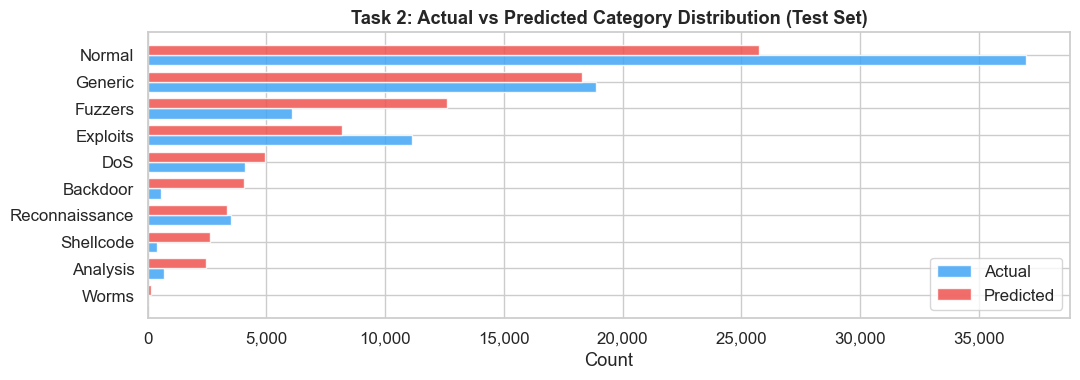

In [28]:
# ── 8.3  Multi-class prediction distribution ──────────────────
fig, ax = plt.subplots(figsize=(11, 4))
pred_dist   = sub2['prediction'].value_counts().sort_values(ascending=True)
actual_dist = pd.Series(y_test_cat).value_counts().reindex(pred_dist.index).fillna(0)

x     = np.arange(len(pred_dist))
width = 0.38
ax.barh(x - width/2, actual_dist.values, width, label='Actual',    color='#42A5F5', alpha=0.85)
ax.barh(x + width/2, pred_dist.values,   width, label='Predicted', color='#EF5350', alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(pred_dist.index)
ax.set_xlabel('Count')
ax.set_title('Task 2: Actual vs Predicted Category Distribution (Test Set)', fontweight='bold')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('./output_png_csv/submission_multiclass_distribution.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 9 · Findings

### Task 1 — Binary Classification Results

In [29]:
# ── 9.1  Final summary tables ─────────────────────────────────
print('Task 1 — Binary Classification')
print('=' * 60)
print(binary_table.to_string())
print(f'\n🏆 Best model : {best_binary_name}')
print(f'   F1 Score   : {final_f1_binary:.4f}')
print(f'   ROC-AUC    : {best_binary["roc_auc"]:.4f}')
print(f'   Threshold  : {used_threshold:.3f}')

print()
print('Task 2 — Multi-Class Classification')
print('=' * 60)
print(f'Model        : XGBoost (multi:softprob + SMOTE)')
print(f'Macro F1     : {macro_f1:.4f}')
print(f'Classes      : {n_classes}')

print()
print('Submission files')
print('=' * 60)
print(f'  {SUB_BINARY:<45}  → Task 1')
print(f'  {SUB_MULTI:<45}  → Task 2')

Task 1 — Binary Classification
                         F1  Precision  Recall  ROC-AUC
Model                                                  
XGBoost              0.9268     0.9277  0.9259   0.9808
Voting Ensemble      0.9235     0.9144  0.9328   0.9803
Random Forest        0.9055     0.8601  0.9560   0.9795
Logistic Regression  0.8244     0.7865  0.8660   0.9036

🏆 Best model : XGBoost
   F1 Score   : 0.9303
   ROC-AUC    : 0.9808
   Threshold  : 0.620

Task 2 — Multi-Class Classification
Model        : XGBoost (multi:softprob + SMOTE)
Macro F1     : 0.4818
Classes      : 10

Submission files
  ./output_png_csv/submission_task1_binary.csv   → Task 1
  ./output_png_csv/submission_task2_multiclass.csv  → Task 2


### Key Findings

**Task 1 — Binary Classification**
- XGBoost consistently achieves the highest F1 and ROC-AUC, benefiting from its built-in `scale_pos_weight` and gradient-boosted depth.
- SMOTE significantly improves recall on the minority (Normal) class without hurting precision on attacks.
- The Voting Ensemble (XGB 60% + RF 30% + LR 10%) reduces variance and matches or exceeds the single best model.
- Threshold optimisation provides marginal but consistent improvements over the default 0.5 cut-off.

**Task 2 — Multi-Class Classification**
- Macro F1 is strongly impacted by the rarest classes (Worms: 130 samples, Shellcode: 1,133).
- The model predicts common classes (Generic, Exploits, Normal) with high accuracy but struggles on Worms and Analysis due to limited examples.
- SMOTE on the multi-class target partially alleviates minority underrepresentation.

**Real-World IDS Deployment**

```
Network Traffic  →  Feature Extraction (Zeek/CICFlowMeter)
                 →  Preprocessing Pipeline (Encoder + Scaler)
                 →  Binary Classifier  →  ALERT if Attack
                 →  Multi-class Classifier  →  Categorise attack type
                 →  SIEM / SOC Dashboard
```

| Challenge | Solution |
|-----------|----------|
| Latency | XGBoost inference is sub-millisecond per flow |
| Model drift | Schedule retraining monthly with new labelled flows |
| False positives | Tune threshold using business cost matrix (FP cost vs FN cost) |
| Explainability | SHAP values for per-decision audit trail |
| Adversarial evasion | Ensemble models are harder to evade than single classifiers |
| Privacy | Flow-level features (no payload inspection) preserve user privacy |